In [1]:
from classes import Function, Convolution, PoissonProcess
from functions import neuron_kernel,sigmoid
import numpy as np

In [2]:
DELTA_T = 0.01
INTERVAL = 21.5

x_values = np.arange(0, INTERVAL , DELTA_T)
functions = [
                (1.5, lambda x: -1),
                (2, lambda x: 1),
                (2, lambda x: -1),
                (2, lambda x: 0),
                (5, lambda x: np.sin(np.pi * np.power(x,2))),
                (2, lambda x: 0),
                (5, lambda x: 0.2 * x * np.sin(3 * np.pi * x)),
                (2, lambda x: 0)
            ]

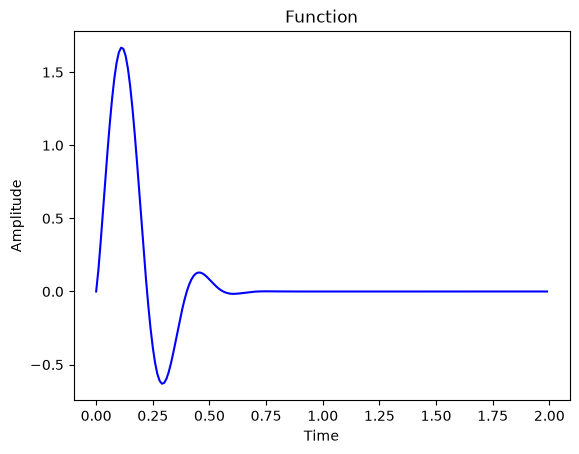

In [3]:
stimulus = Function(functions=functions, x_values=x_values)
# ON-fast-sustained
p = 1
l = 0.4
v = 1.2

neuron = Function(
    functions=[
        (2, neuron_kernel(p, l, v)) #2 seconds so the array dosen't get crazy long 
    ],
    x_values=np.arange(0, 2, DELTA_T)
)
neuron.graph()

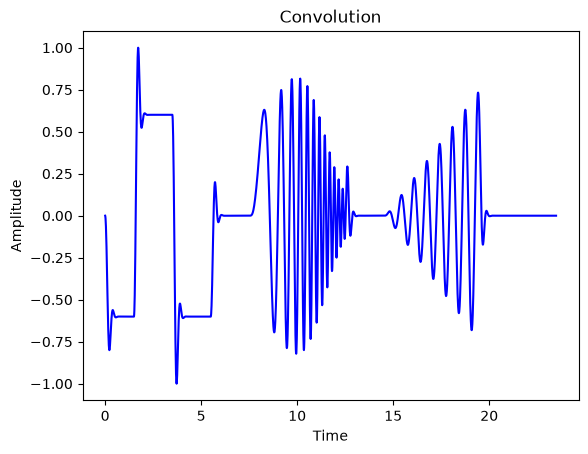

In [4]:
convolution = Convolution(stimulus, neuron, min_max=True, delta_t=DELTA_T)
convolution.graph()

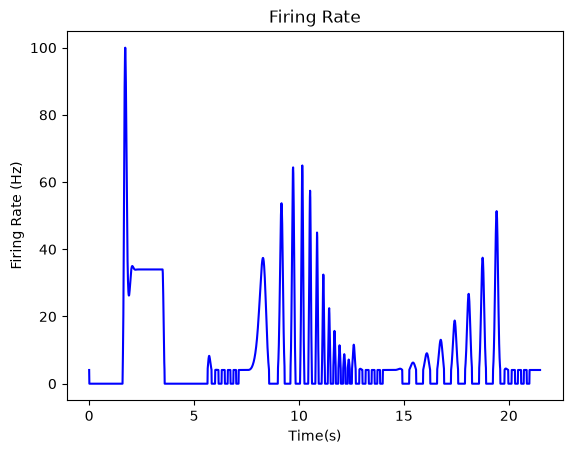

In [5]:
rate = Function(
    functions=[
        (round(np.max(convolution.y_values) - np.min(convolution.y_values),1), sigmoid(max_value=100, min_value=0.5, gain=4, offset=1))
    ],
    x_values=convolution.y_values
)


rate.graph(name="Firing Rate", x_label="Time(s)", y_label="Firing Rate (Hz)", alt_graph_x_values=x_values)

In [6]:
rate.y_values

array([4.07925578, 0.        , 0.        , ..., 4.07925578, 4.07925578,
       4.07925578], shape=(2349,))

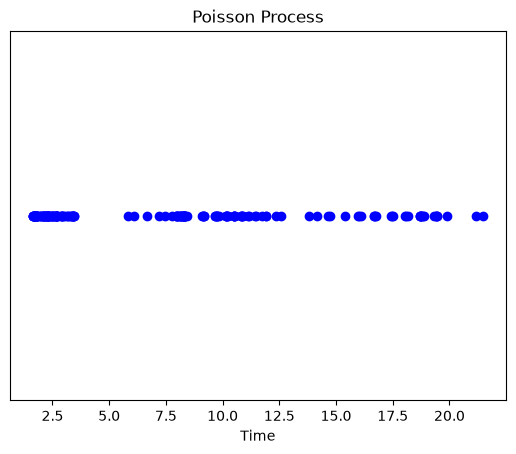

In [8]:

points = PoissonProcess(rate_values=rate.y_values, max_time=INTERVAL, time_delta= DELTA_T)
points.graph()